# Predicting whether a patient has Heart Disease using Machine Learning

**The goal is to build and tune a Machine Learning model capable of predicting whether or not someone has Heart Disease based on their medical attributes.**

Framework to follow:

1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimenation

## 1. Problem Definition

> Given medical attributes about a patient, can we predict whether they have Heart Disease or not?

## 2. Data

The data came from the Cleveland Database from the UCI Machine Learning Repository - https://archive.ics.uci.edu/dataset/45/heart+disease

## 3. Evaluation

> If we can reach 90% accuracy at predicting whether or not a patient has Heart Disease during this proof of concept, we'll pursure with the project.

## 4. Features

1. `age`: age in years
2. `sex`: sex (1 = male; 0 = female)
3. `cp`: chest pain type
    * Value 1: typical angina
    * Value 2: atypical angina
    * Value 3: non-anginal pain
    * Value 4: asymptomatic

4. `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
5. `chol`: serum cholestoral in mg/dl
6. `fbs`: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7. `restecg`: resting electrocardiographic results
    * Value 0: normal
    * Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    * Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

8. `thalach`: maximum heart rate achieved
9. `exang`: exercise induced angina (1 = yes; 0 = no)
10. `oldpeak` = ST depression induced by exercise relative to rest
11. `slope`: the slope of the peak exercise ST segment
    * Value 1: upsloping
    * Value 2: flat
    * Value 3: downsloping

12. `ca`: number of major vessels (0-3) colored by flourosopy
13. `thal`: 3 = normal; 6 = fixed defect; 7 = reversable defect
14. `target`: (1 = Heart Disease; 0 = No Heart Disease) `The predicted attribute`

## Importing the tools to use

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 
import seaborn as sns

%matplotlib inline

## Load Data

In [5]:
df = pd.read_csv("heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## EDA (Exploratory Data Analysis)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.shape

(303, 14)

In [11]:
# Check for missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [14]:
# To see the different counts of classes
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

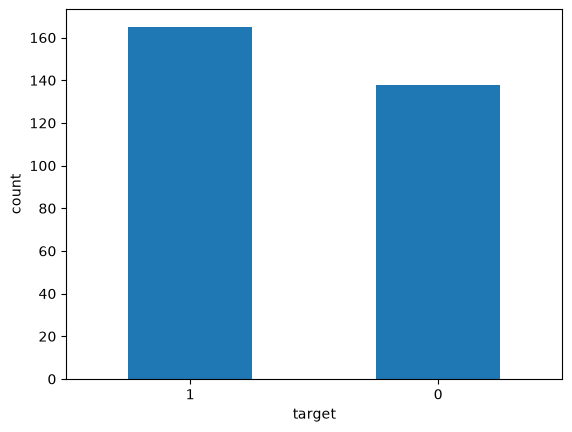

In [24]:
df["target"].value_counts().plot(kind = "bar",
                                 xlabel = "target",
                                 ylabel = "count",
                                 rot = 0);

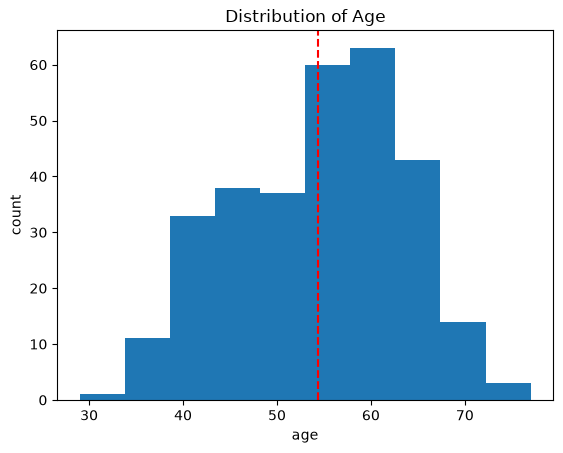

In [32]:
# Distribution of Age with mean line 
fig, ax = plt.subplots()
ax.hist(df["age"])
ax.set(xlabel = "age",
       ylabel = "count",
       title = "Distribution of Age")

ax.axvline(df["age"].mean(),
           color = "red",
           linestyle = "--");

In [33]:
df["sex"].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

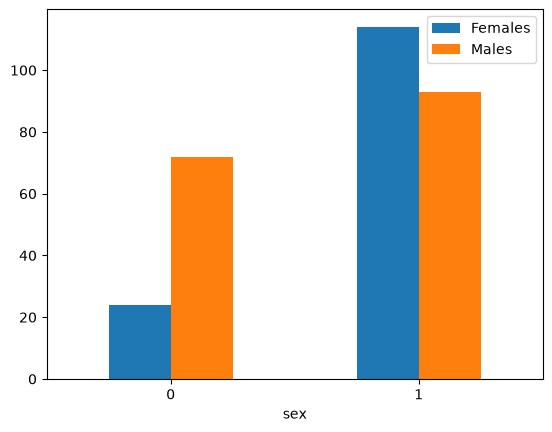

In [43]:
# Comparing 'sex' column to 'target' column using bar graph
pd.crosstab(df["sex"], df["target"]).plot(kind = "bar");

plt.xlabel = "0 = No Heart Disease, 1 = Has Heart Disease"
plt.ylabel = "Count"
plt.title = "Heart Disease Frequency for each Sex"
plt.legend(["Females", "Males"])
plt.xticks(rotation = 0);

In [44]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


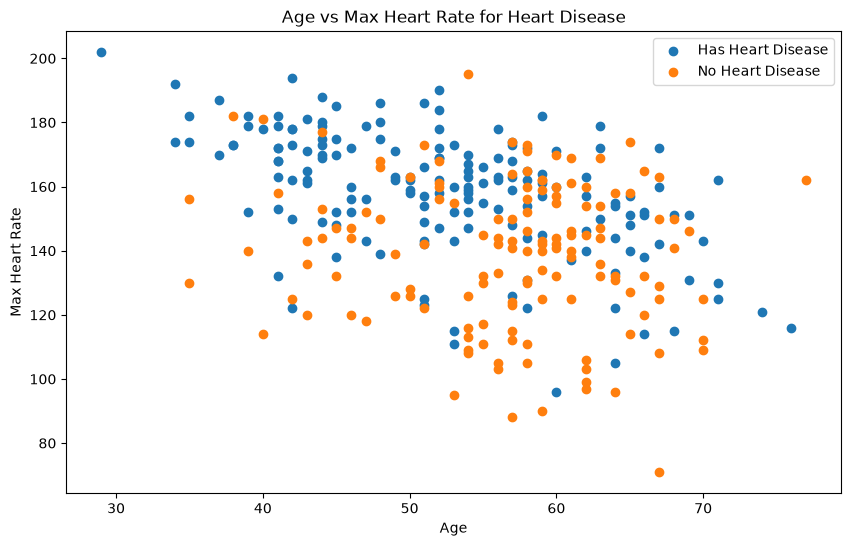

In [60]:
# Comparing Age vs Max Heart rate (thalach) for Heart Disease
fig, ax = plt.subplots(figsize = (10, 6))

# Scatter plot for Heart Disease
ax.scatter(df["age"][df["target"] == 1],
           df["thalach"][df["target"] == 1])

# Scatter plot for NO Heart Disease
ax.scatter(df["age"][df["target"] == 0],
           df["thalach"][df["target"] == 0])

# Customising the plot
ax.set(xlabel = "Age",
       ylabel = "Max Heart Rate",
       title = "Age vs Max Heart Rate for Heart Disease")
ax.legend(["Has Heart Disease", "No Heart Disease"]);